In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from PIL import Image

print("All imports OK")

All imports OK


In [3]:
# Load SROIE entities (labels)
sroie_train_entities = Path("../data/sroie/train/entities")
sroie_train_images = Path("../data/sroie/train/img")

records = []
for f in sroie_train_entities.glob("*.txt"):
    try:
        with open(f, encoding="utf-8") as fp:
            data = json.load(fp)
        data["file"] = f.stem
        records.append(data)
    except Exception as e:
        print(f"Error reading {f.name}: {e}")

df_sroie = pd.DataFrame(records)
print(f"Loaded {len(df_sroie)} SROIE training samples")
print(df_sroie.head())

Loaded 626 SROIE training samples
                           company        date  \
0  BOOK TA .K (TAMAN DAYA) SDN BHD  25/12/2018   
1           INDAH GIFT & HOME DECO  19/10/2018   
2        MR D.I.Y. (JOHOR) SDN BHD    12-01-19   
3              YONGFATT ENTERPRISE  25/12/2018   
4            MR D.I.Y. (M) SDN BHD    18-11-18   

                                             address  total          file  
0  NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...   9.00  X00016469612  
1  27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...  60.30  X00016469619  
2  LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...  33.90  X00016469620  
3       NO 122.124. JALAN DEDAP 13 81100 JOHOR BAHRU  80.90  X00016469622  
4  LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...  30.90  X00016469623  


In [4]:
print("=== SROIE Field Summary ===")
print(df_sroie.describe(include="all"))
print("\n=== Missing Values ===")
print(df_sroie.isnull().sum())

=== SROIE Field Summary ===
                               company        date  \
count                              626         626   
unique                             236         493   
top     GARDENIA BAKERIES (KL) SDN BHD  20/03/2018   
freq                                45           5   

                                                  address  total          file  
count                                                 625    626           626  
unique                                                291    478           626  
top     LOT 3, JALAN PELABUR 23/1, 40300 SHAH ALAM, SE...  $8.20  X00016469612  
freq                                                   46     12             1  

=== Missing Values ===
company    0
date       0
address    1
total      0
file       0
dtype: int64


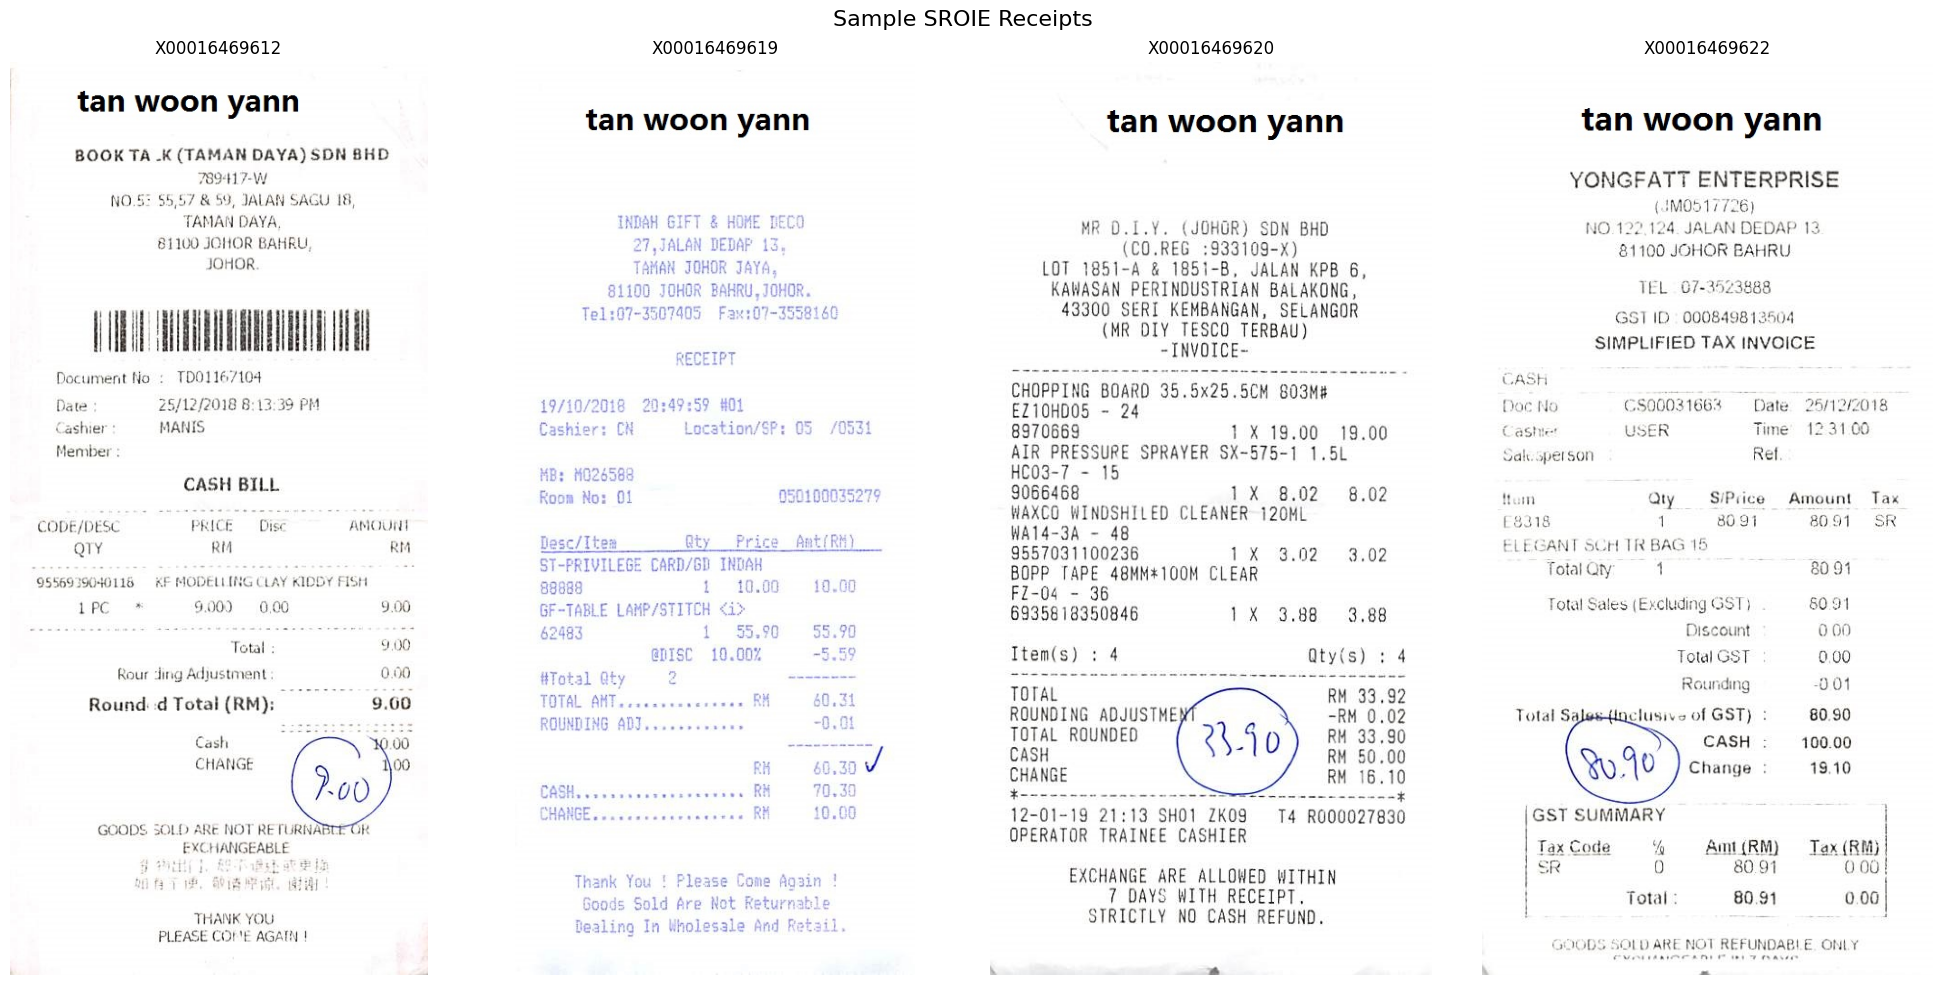

In [5]:
images = list(sroie_train_images.glob("*.jpg"))[:4]

fig, axes = plt.subplots(1, 4, figsize=(20, 10))
for ax, img_path in zip(axes, images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.stem[:15])
plt.suptitle("Sample SROIE Receipts", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
with open(finditagain_root / "train.txt", encoding="utf-8") as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i > 5:
            break

'image,digital annotation,handwritten annotation,forged,forgery annotations\n'
'X00016469622.png,1,1,1,"{\'filename\': \'X00016469622.png\', \'size\': 230726, \'regions\': [{\'shape_attributes\': {\'name\': \'rect\', \'x\': 248, \'y\': 459, \'width\': 13, \'height\': 18}, \'region_attributes\': {\'Modified area\': {\'CPI\': True}, \'Entity type\': \'Product\', \'Original area\': \'no\'}}, {\'shape_attributes\': {\'name\': \'rect\', \'x\': 405, \'y\': 342, \'width\': 13, \'height\': 17}, \'region_attributes\': {\'Modified area\': {\'None\': True}, \'Original area\': \'yes\', \'Entity type\': \'Metadata\'}}, {\'shape_attributes\': {\'name\': \'rect\', \'x\': 345, \'y\': 461, \'width\': 9, \'height\': 16}, \'region_attributes\': {\'Modified area\': {\'CPI\': True}, \'Entity type\': \'Product\', \'Original area\': \'no\'}}, {\'shape_attributes\': {\'name\': \'rect\', \'x\': 347, \'y\': 510, \'width\': 8, \'height\': 16}, \'region_attributes\': {\'Modified area\': {\'CPI\': True}, \'Entity 

In [10]:
import csv

def load_finditagain_labels(txt_file):
    records = []
    with open(txt_file, encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)  # skip header row
        for row in reader:
            if len(row) < 4:
                continue
            filename = row[0]
            is_forged = int(row[3]) if row[3].strip().isdigit() else 0
            records.append({"file": filename, "is_forged": is_forged})
    return pd.DataFrame(records)

df_train_labels = load_finditagain_labels(finditagain_root / "train.txt")
df_val_labels   = load_finditagain_labels(finditagain_root / "val.txt")
df_test_labels  = load_finditagain_labels(finditagain_root / "test.txt")

print(f"Train: {len(df_train_labels)} samples, {df_train_labels['is_forged'].sum()} forged")
print(f"Val:   {len(df_val_labels)} samples, {df_val_labels['is_forged'].sum()} forged")
print(f"Test:  {len(df_test_labels)} samples, {df_test_labels['is_forged'].sum()} forged")

Train: 577 samples, 94 forged
Val:   193 samples, 34 forged
Test:  218 samples, 35 forged


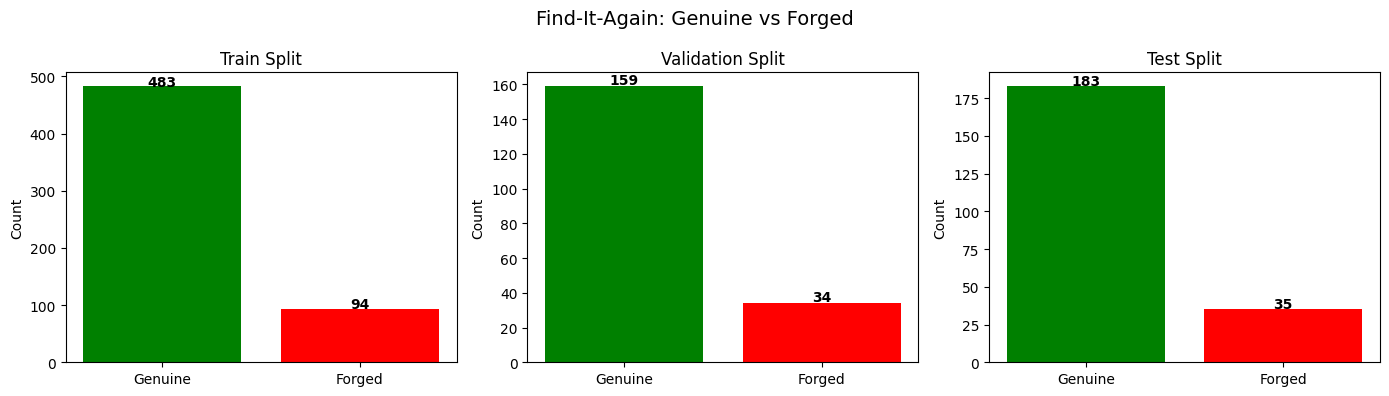

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (df, split) in zip(axes, [
    (df_train_labels, "Train"),
    (df_val_labels,   "Validation"),
    (df_test_labels,  "Test")
]):
    counts = df["is_forged"].value_counts().sort_index()
    ax.bar(["Genuine", "Forged"], counts.values, color=["green", "red"])
    ax.set_title(f"{split} Split")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.suptitle("Find-It-Again: Genuine vs Forged", fontsize=14)
plt.tight_layout()
plt.show()